In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob

In [9]:
def boxcount(Z, k):
    S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
            np.arange(0, Z.shape[1], k), axis=1)
    return np.count_nonzero(S)

def fractal_dimension_image(filename, t=150, plot=True):
    img = Image.open(filename).convert("L")
    I = np.array(img, dtype=float)

    # struktur = mørke pixels
    Z = (I < t).astype(int)

    p = min(Z.shape)
    n = int(np.floor(np.log2(p)))
    sizes = 2**np.arange(n, 1, -1)

    counts = np.array([boxcount(Z, s) for s in sizes], dtype=float)

    x = np.log(1.0 / sizes)
    y = np.log(counts)
    D, a = np.polyfit(x, y, 1)

    if plot:
        plt.figure(figsize=(5,4))
        plt.plot(x, y, 'o-', label='data')
        plt.plot(x, a + D*x, 'r--', label=f'fit, D={D:.3f}')
        plt.xlabel("log(1/box size)")
        plt.ylabel("log(N(boxes))")
        plt.legend()
        plt.title(filename)
        plt.tight_layout()
        plt.show()

    return D

# kør for alle .jpg i mappen
files = sorted(glob.glob("*.jpg"))

results = []
for f in files:
    D = fractal_dimension_image(f, t=150, plot=False)  # plot=False hvis du kun vil have tal
    results.append((f, D))

# print resultaterne
print("Fil\t\tFraktal-dimension")
for f, D in results:
    print(f"{f}\t{D:.3f}")

Fil		Fraktal-dimension
1i0120a001A.jpg	1.694
DLA_Cluster.jpg	1.666
No1_chsty_fractl_fig1.jpg	1.551
No2_chsty_fractl_fig1.jpg	1.549
Vol29_No3_chsty_fractl_fig1.jpg	1.532
closeup-frozen-surface-winter.jpg	1.726
e0207d109A.jpg	1.713
krystal.jpg	1.781
tree.jpg	1.547


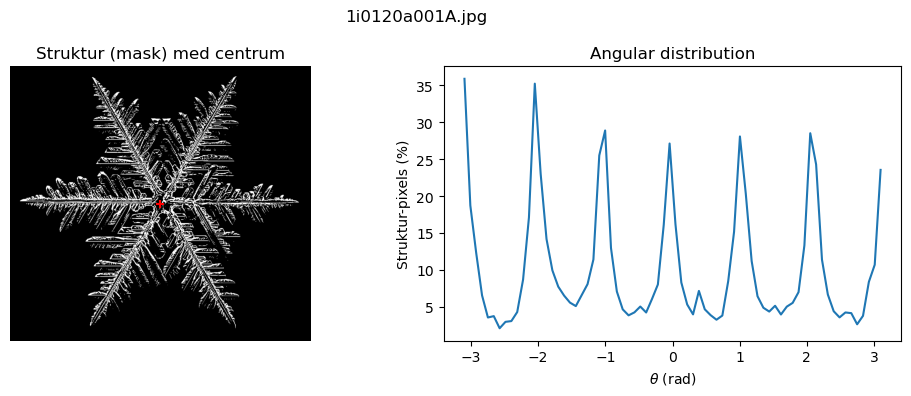

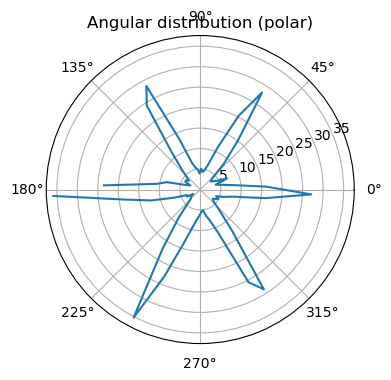

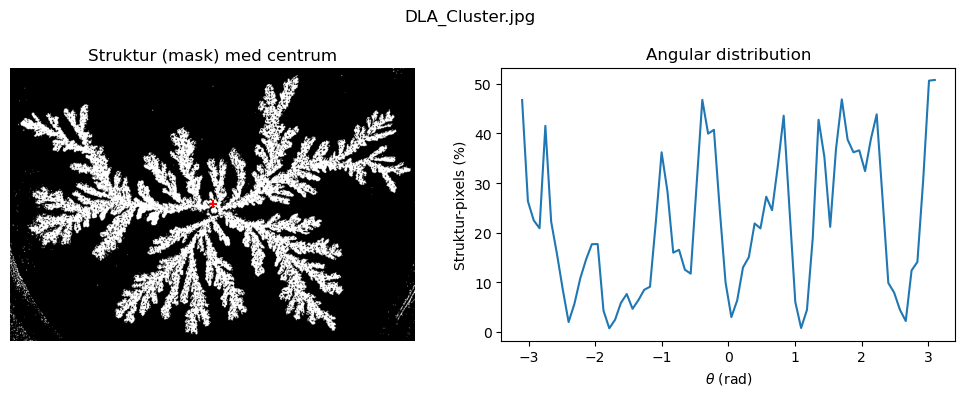

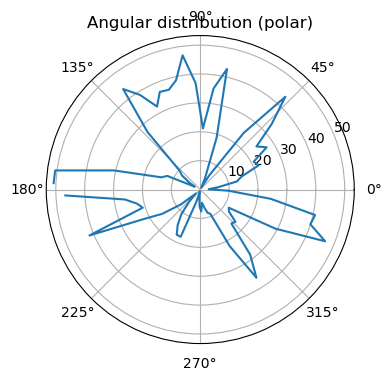

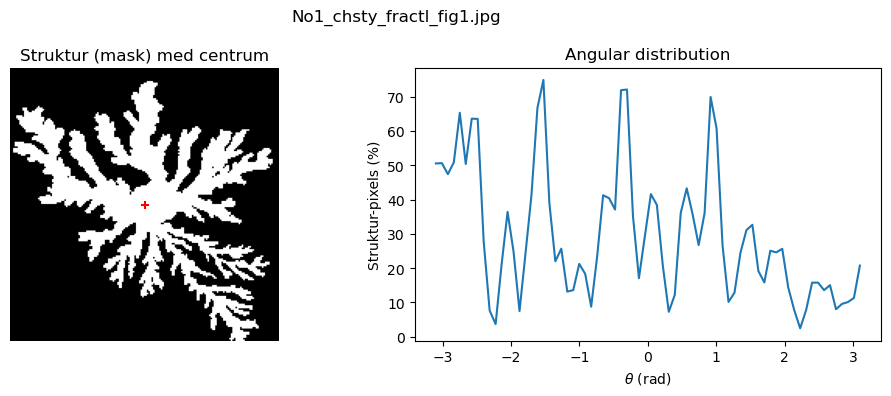

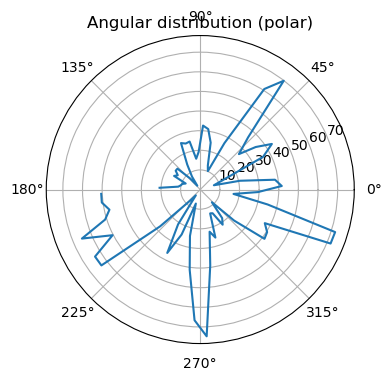

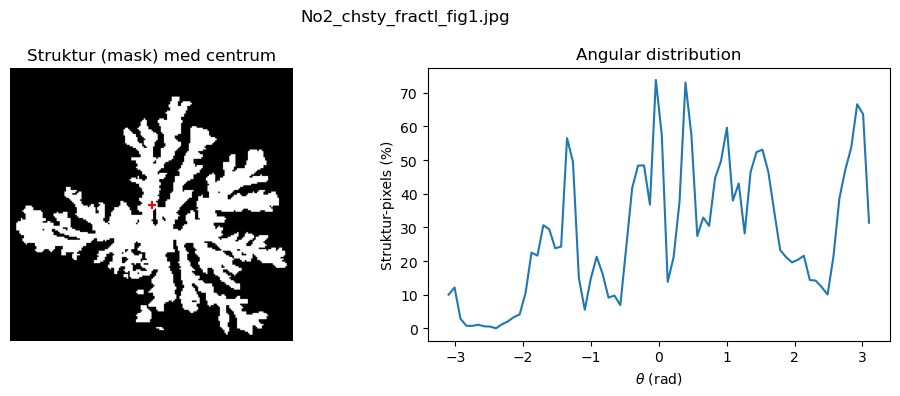

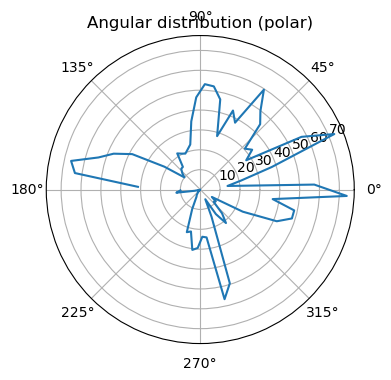

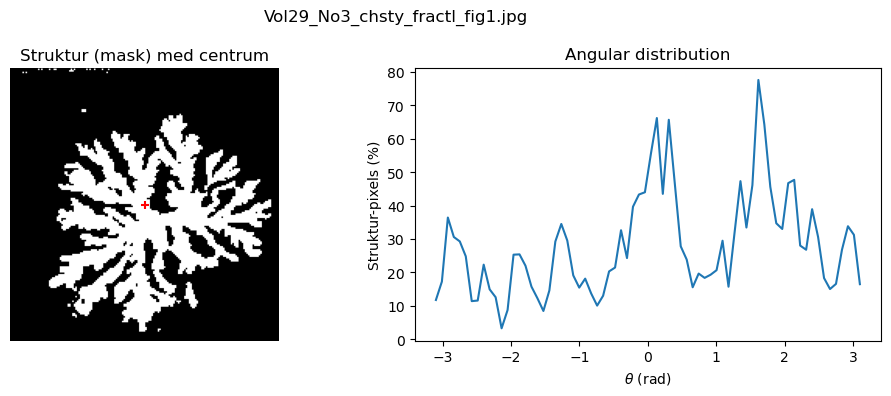

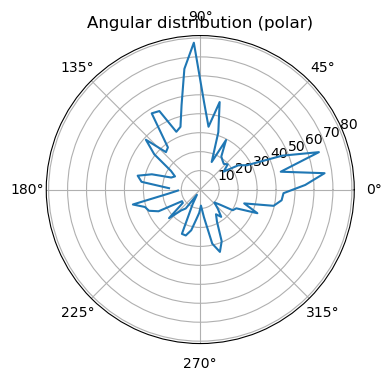

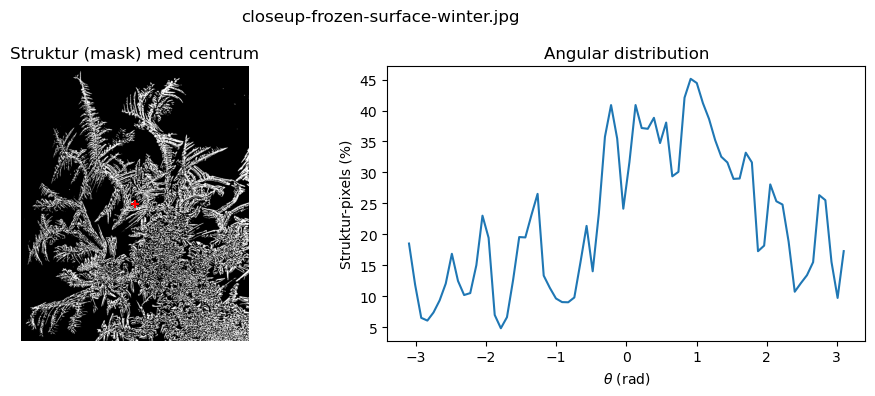

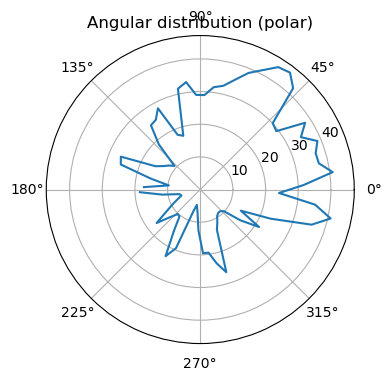

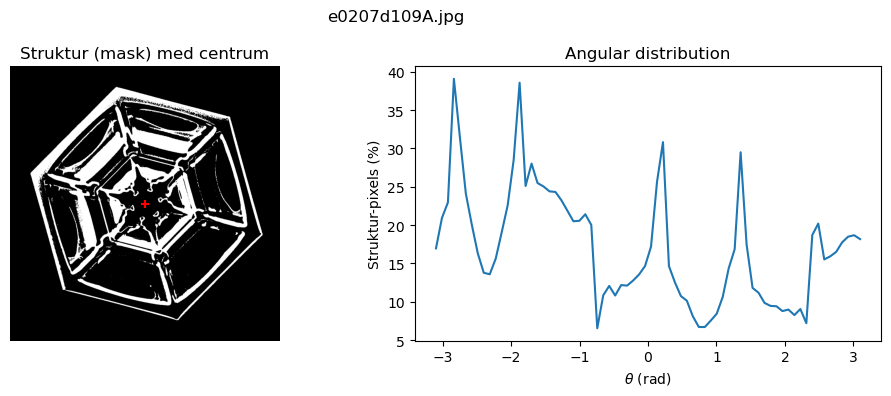

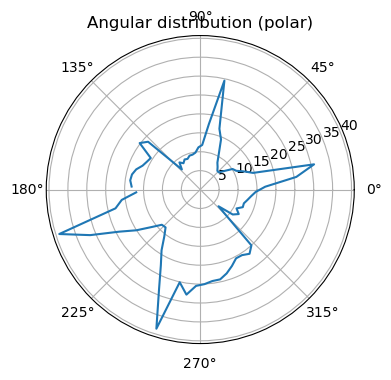

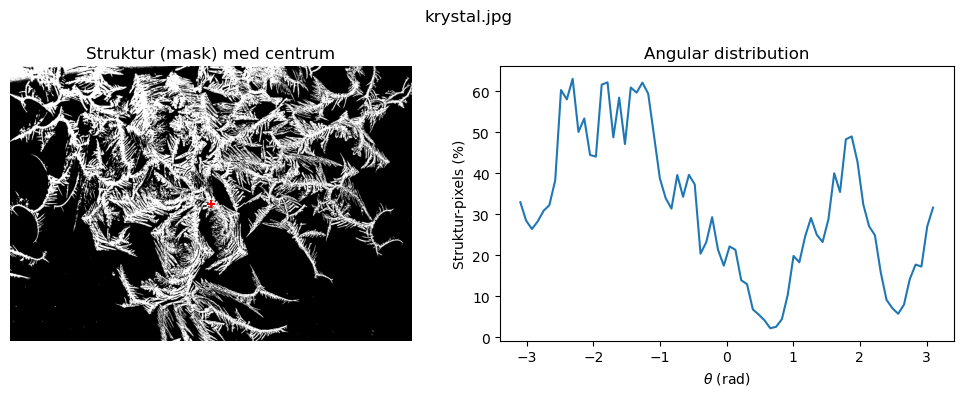

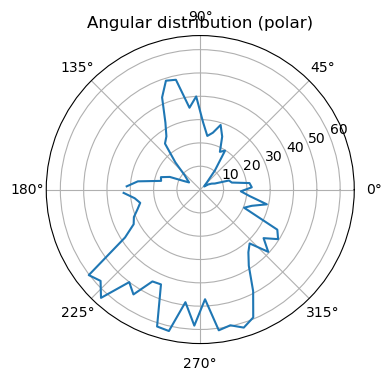

In [6]:
def angular_distribution(filename, t=150, nbins=72):
    img = Image.open(filename).convert("L")
    I = np.array(img, dtype=float)

    ny, nx = I.shape
    cx, cy = nx / 2.0, ny / 2.0

    y, x = np.indices((ny, nx))
    # vinkel i [-pi, pi]
    theta = np.arctan2(y - cy, x - cx)

    # struktur = mørke pixels (samme idé som før)
    struct_mask = (I < t).astype(float)

    # histogram over vinkel
    bin_edges = np.linspace(-np.pi, np.pi, nbins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    N_total, _ = np.histogram(theta, bins=bin_edges)                 # alle pixels
    N_struct, _ = np.histogram(theta, bins=bin_edges, weights=struct_mask)

    frac_struct = np.zeros_like(bin_centers)
    valid = N_total > 0
    frac_struct[valid] = 100.0 * N_struct[valid] / N_total[valid]    # procent

    return bin_centers, frac_struct, struct_mask, (cx, cy)


files = sorted(glob.glob("*.jpg"))

for f in files:
    th, frac_theta, mask, (cx, cy) = angular_distribution(f, t=150, nbins=72)

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f)

    # billede / struktur + centrum
    axs[0].imshow(mask, cmap="gray")
    axs[0].scatter([cx], [cy], c="red", s=40, marker="+")
    axs[0].set_title("Struktur (mask) med centrum")
    axs[0].axis("off")

    # vinkel-fordeling (kan også tegnes som polær)
    axs[1].plot(th, frac_theta)
    axs[1].set_xlabel(r"$\theta$ (rad)")
    axs[1].set_ylabel("Struktur-pixels (%)")
    axs[1].set_title("Angular distribution")

    plt.tight_layout()
    plt.show()

    # alternativ: polært plot
    plt.figure(figsize=(4,4))
    axp = plt.subplot(111, projection="polar")
    axp.plot(th, frac_theta)
    axp.set_title("Angular distribution (polar)")
    plt.show()

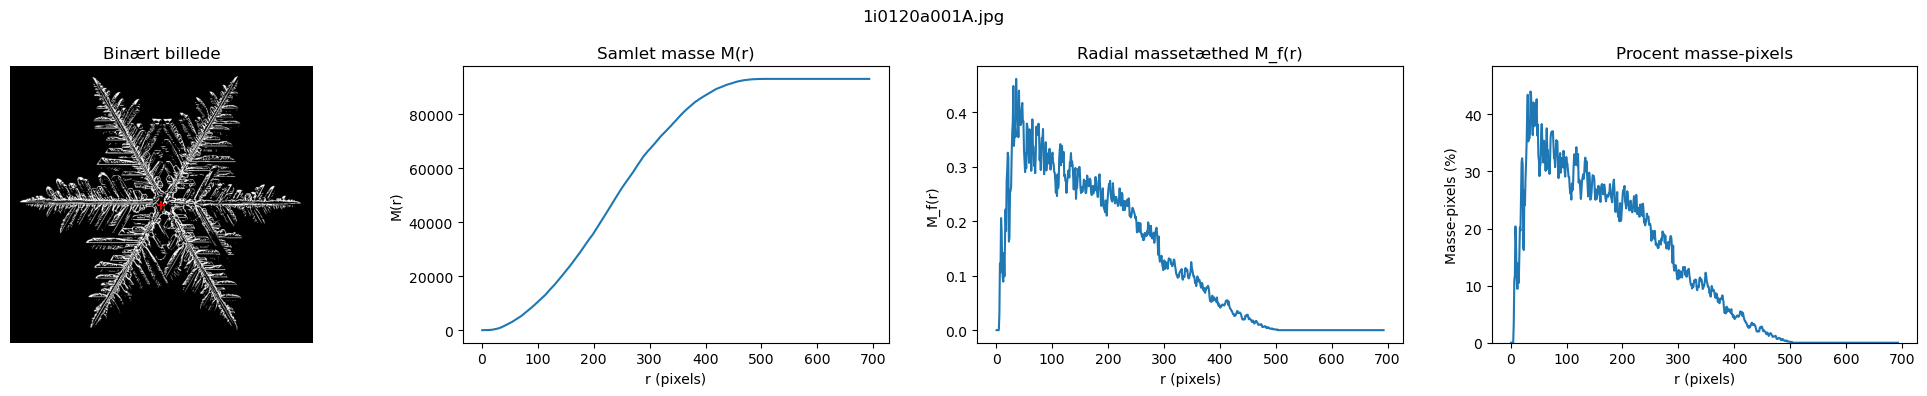

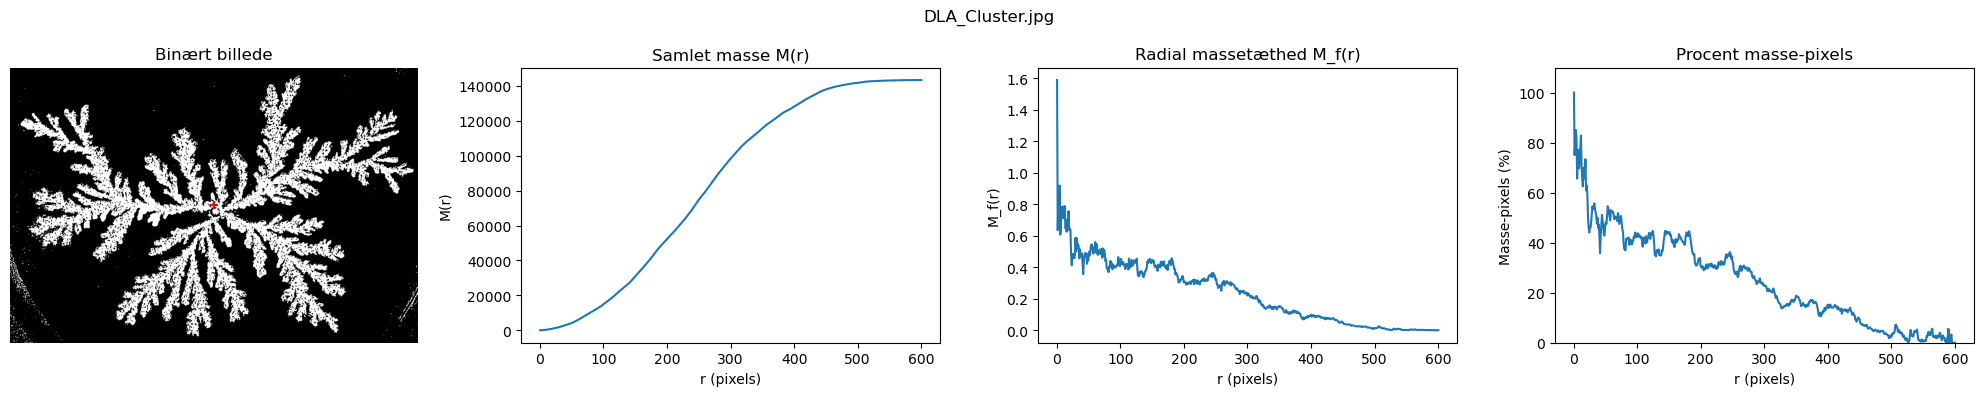

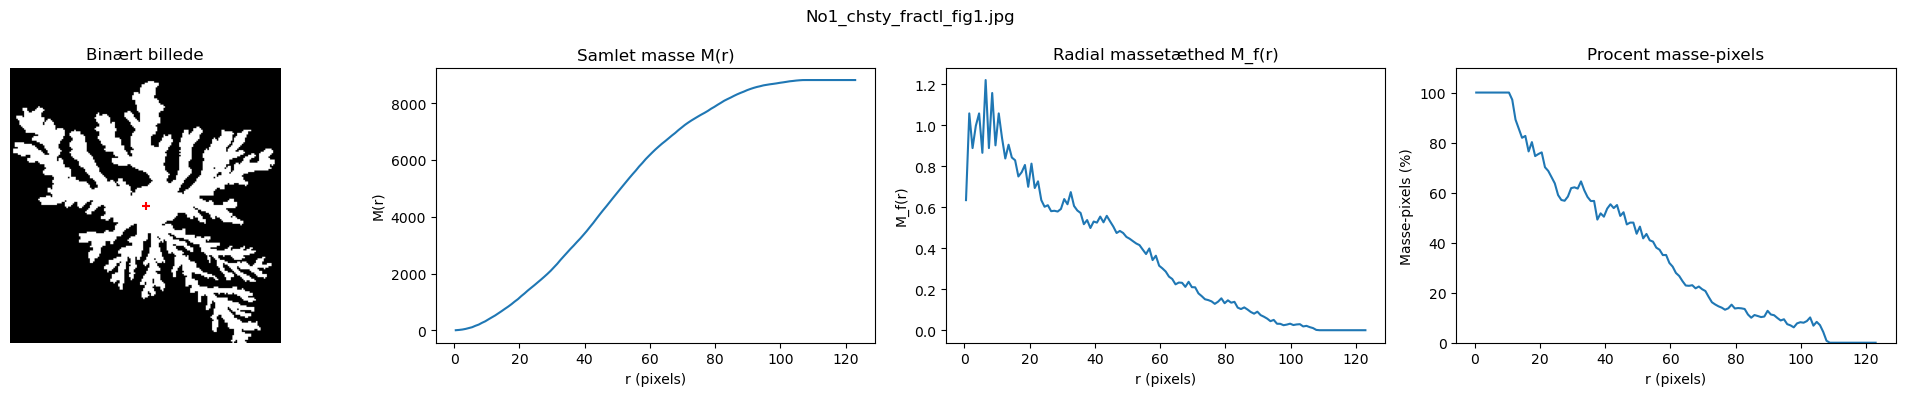

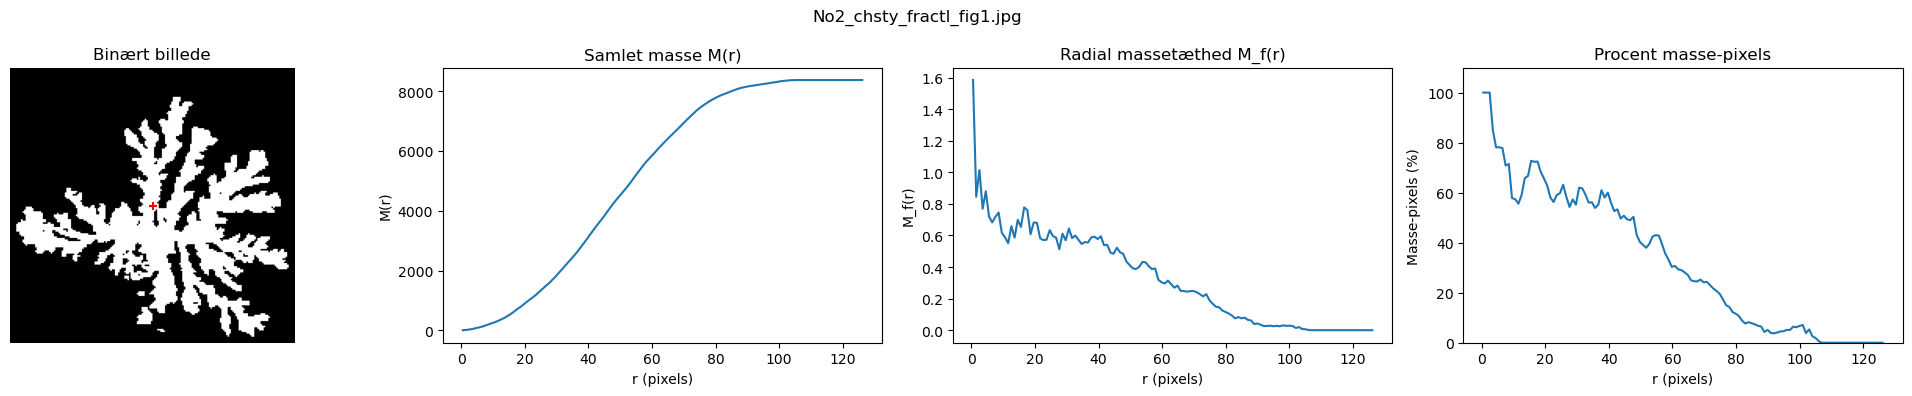

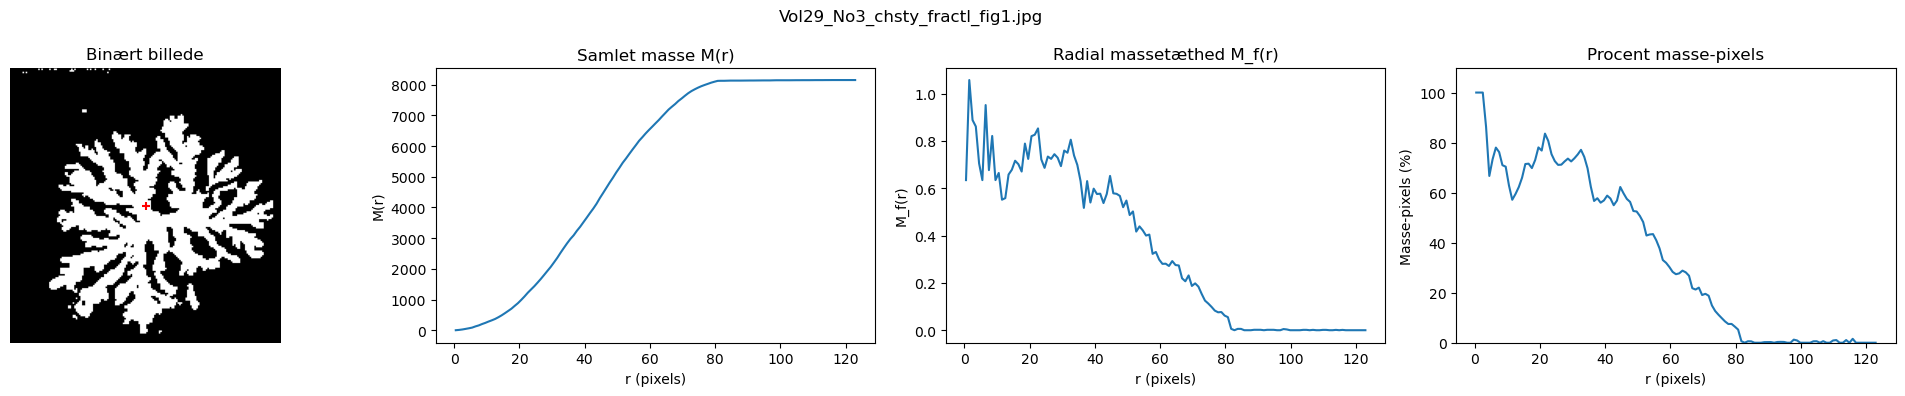

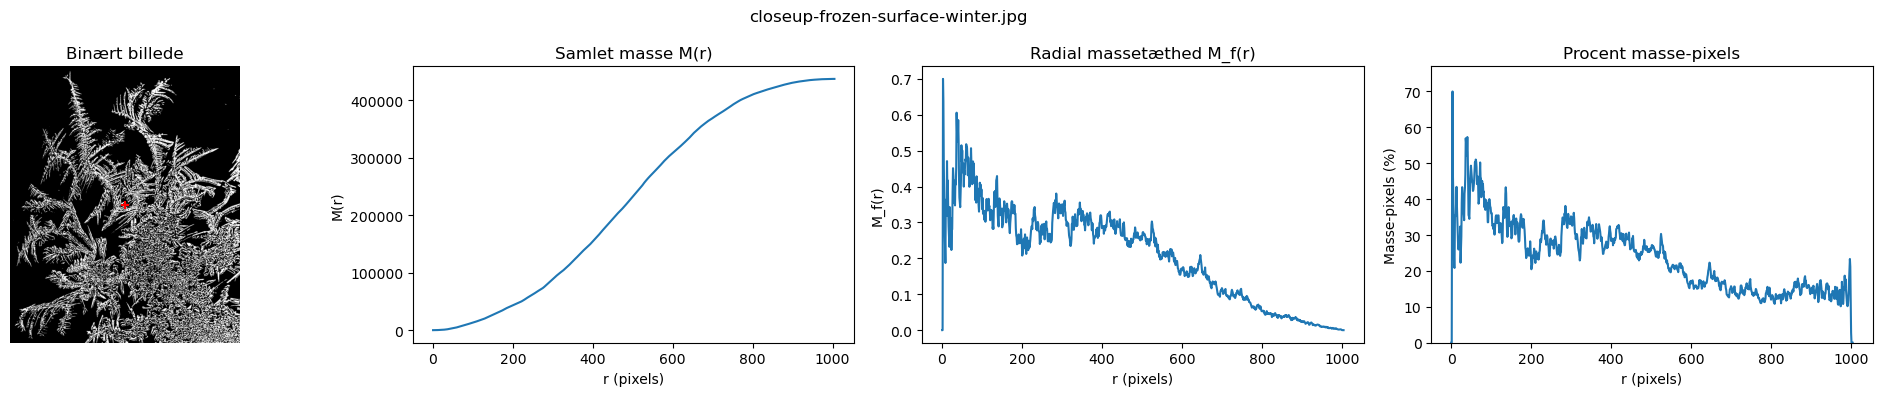

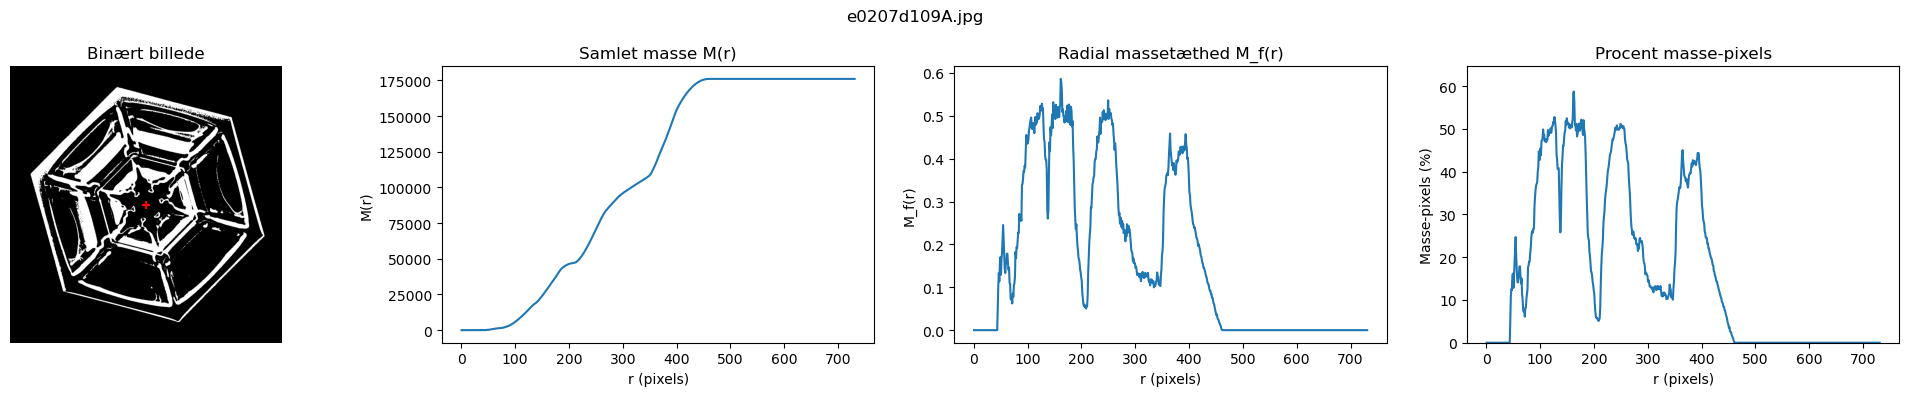

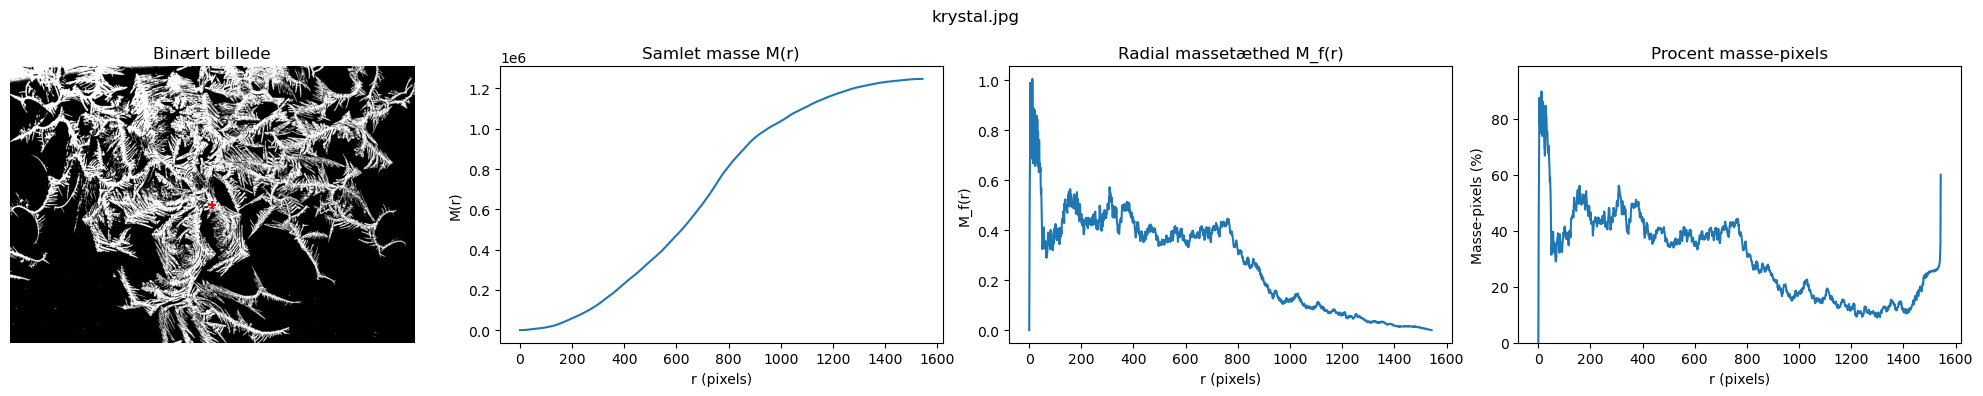

In [5]:


def radial_mass_and_color(filename, t=150, dr=1.0):
    img = Image.open(filename).convert("L")
    I = np.array(img, dtype=float)

    ny, nx = I.shape
    cx, cy = nx / 2.0, ny / 2.0

    y, x = np.indices((ny, nx))
    r = np.sqrt((x - cx)**2 + (y - cy)**2)

    r_max = r.max()
    nbins = int(r_max // dr)
    bin_edges = np.linspace(0, r_max, nbins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # struktur = mørke pixels (I < t)
    structure_mask = (I < t).astype(float)   # 1 = DLA, 0 = baggrund

    # brug den både som "masse" og til procent
    deltaM, _ = np.histogram(r, bins=bin_edges, weights=structure_mask)
    M = np.cumsum(deltaM)
    Mf = deltaM / (2 * np.pi * bin_centers * dr)

    N_total, _ = np.histogram(r, bins=bin_edges)
    N_struct, _ = np.histogram(r, bins=bin_edges, weights=structure_mask)

    frac_struct = np.zeros_like(bin_centers)
    valid = N_total > 0
    frac_struct[valid] = 100.0 * N_struct[valid] / N_total[valid]

    return bin_centers, M, Mf, structure_mask, cx, cy, frac_struct



# vælg alle .jpg billeder i mappen
files = sorted(glob.glob("*.jpg"))

for f in files:
    r, M, Mf, mask, cx, cy, frac_color = radial_mass_and_color(f, t=150, dr=1.0)

    fig, axs = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f)

    # 1) binært billede + centrum
    axs[0].imshow(mask, cmap="gray")
    axs[0].scatter([cx], [cy], c="red", s=40, marker="+")
    axs[0].set_title("Binært billede")
    axs[0].axis("off")

    # 2) M(r)
    axs[1].plot(r, M)
    axs[1].set_xlabel("r (pixels)")
    axs[1].set_ylabel("M(r)")
    axs[1].set_title("Samlet masse M(r)")

    # 3) M_f(r)
    axs[2].plot(r, Mf)
    axs[2].set_xlabel("r (pixels)")
    axs[2].set_ylabel("M_f(r)")
    axs[2].set_title("Radial massetæthed M_f(r)")

    # 4) procent farvede pixels

    axs[3].plot(r, frac_color)
    axs[3].set_xlabel("r (pixels)")
    axs[3].set_ylabel("Masse-pixels (%)")
    axs[3].set_ylim(0, 1.1 * frac_color.max())
    axs[3].set_title("Procent masse-pixels")

    plt.tight_layout()
    plt.show()




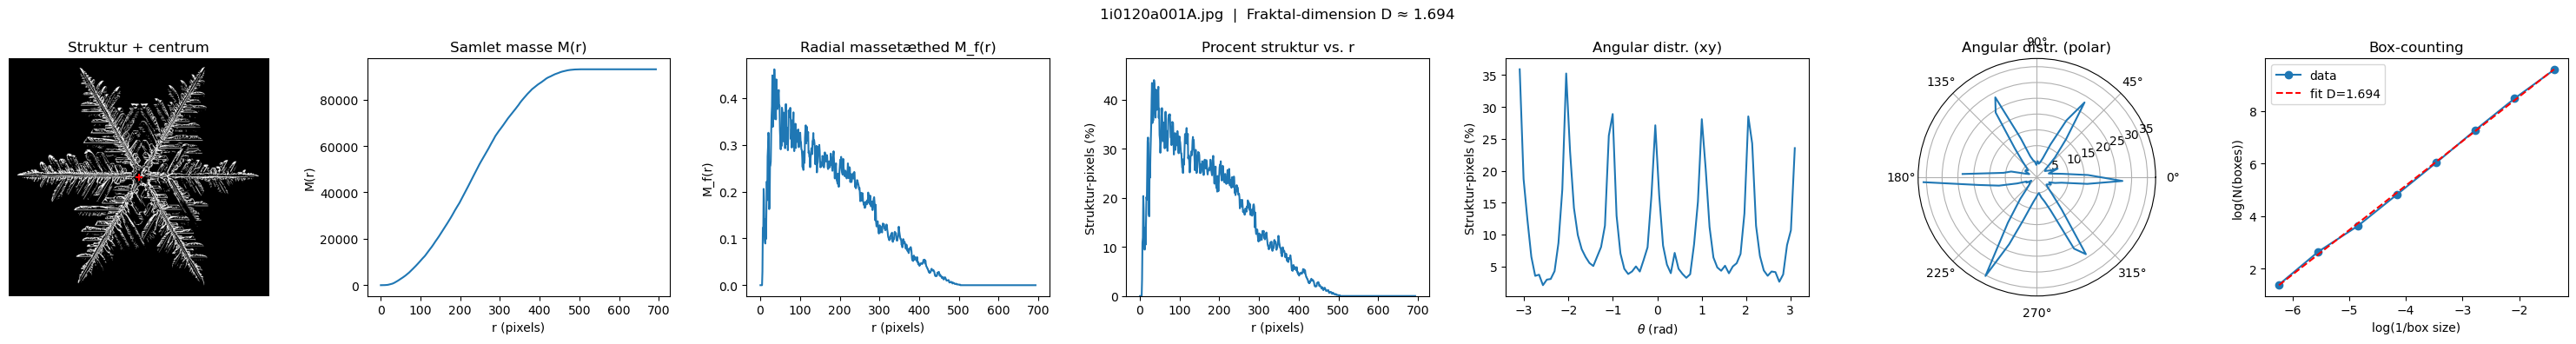

1i0120a001A.jpg: D ≈ 1.694


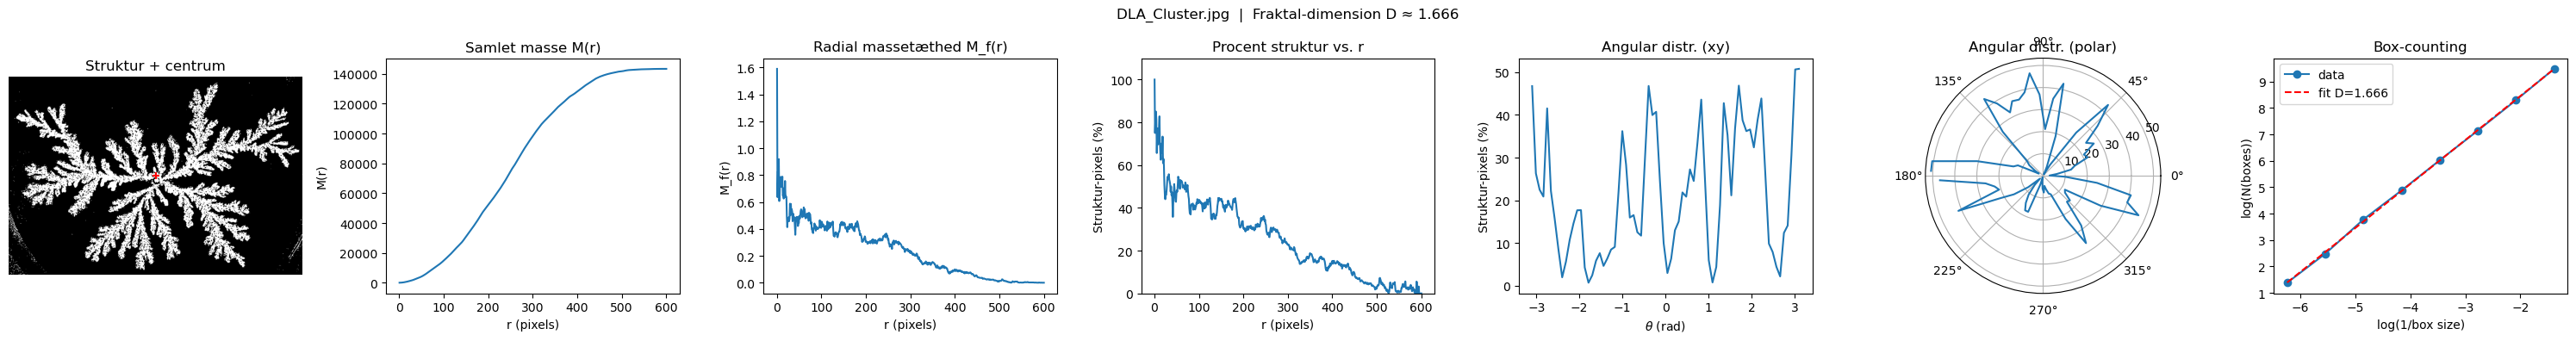

DLA_Cluster.jpg: D ≈ 1.666


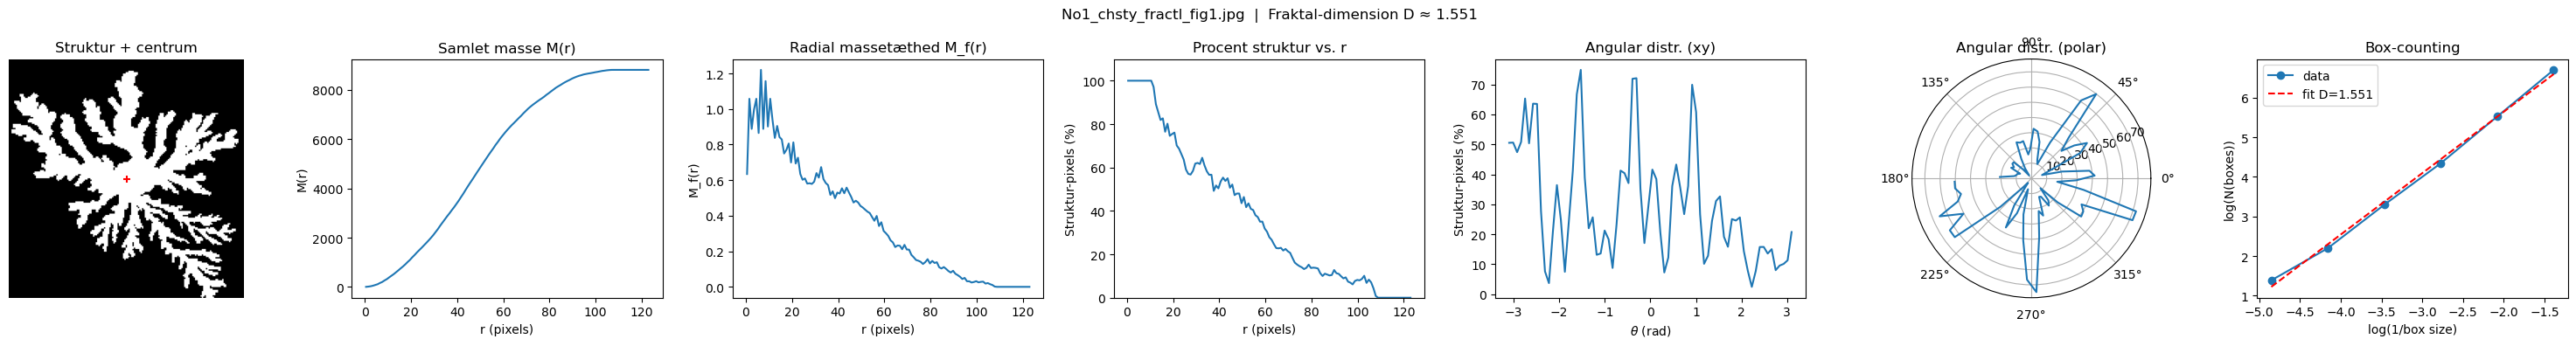

No1_chsty_fractl_fig1.jpg: D ≈ 1.551


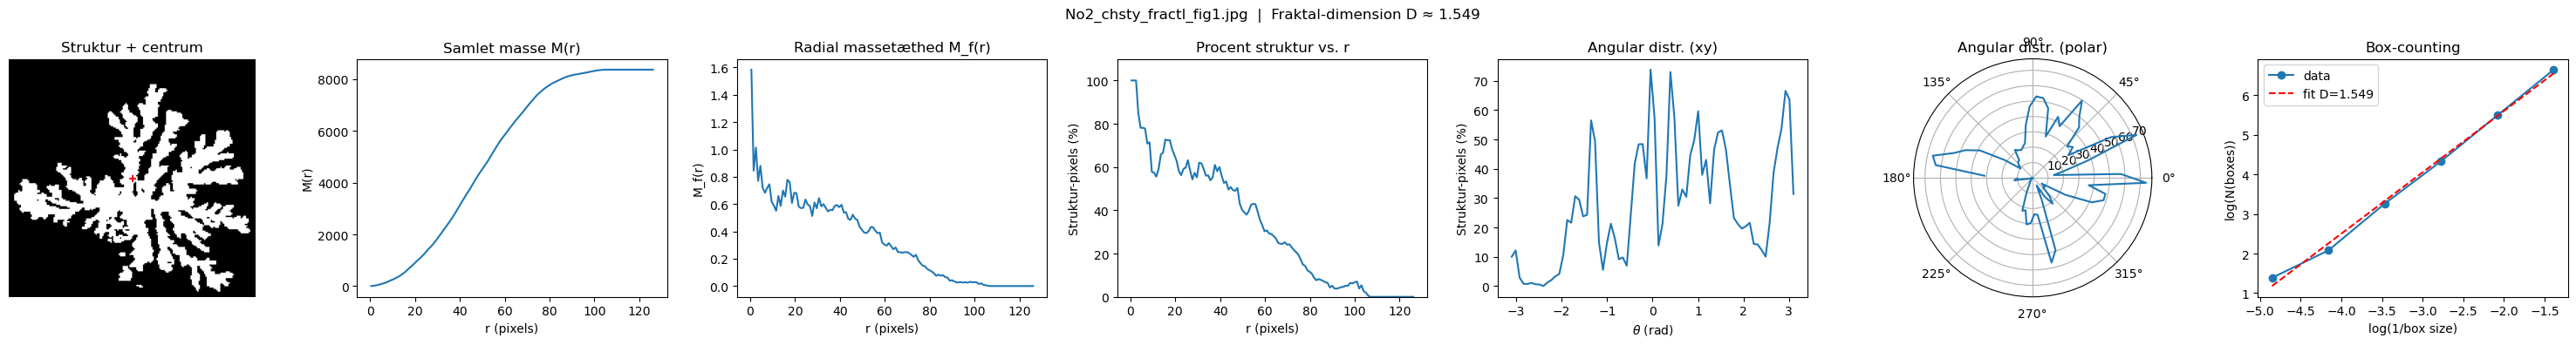

No2_chsty_fractl_fig1.jpg: D ≈ 1.549


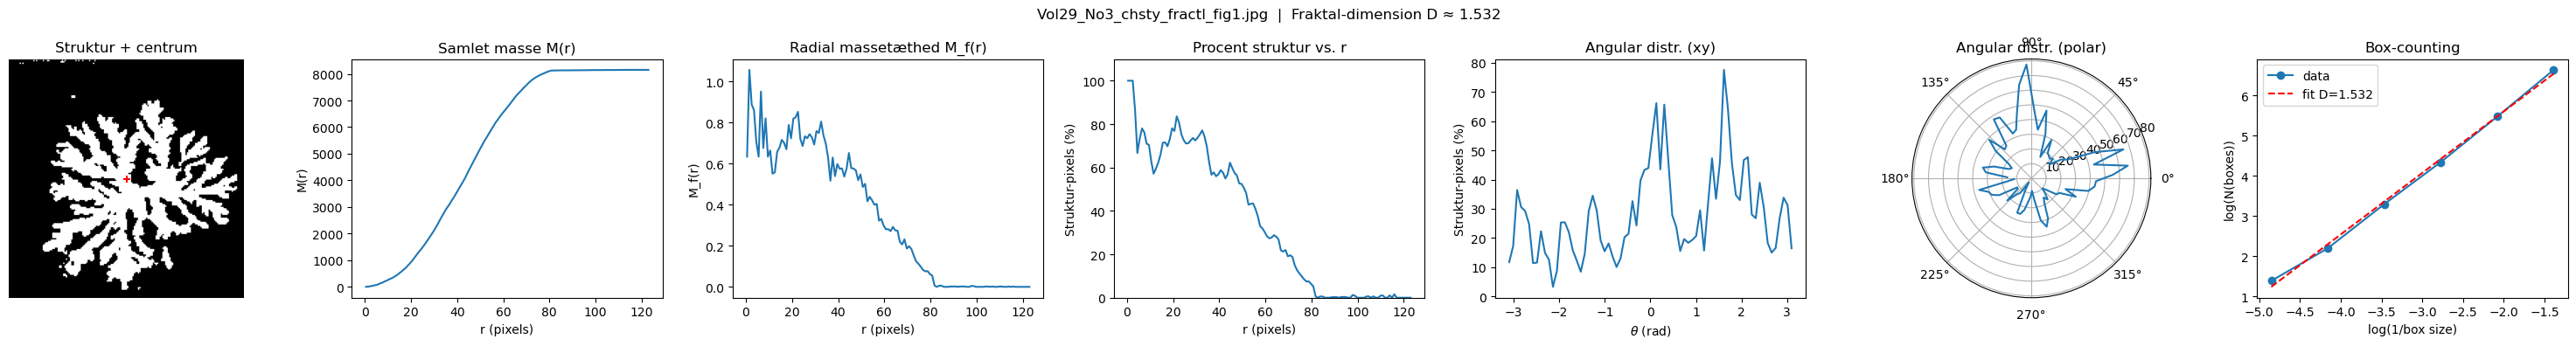

Vol29_No3_chsty_fractl_fig1.jpg: D ≈ 1.532


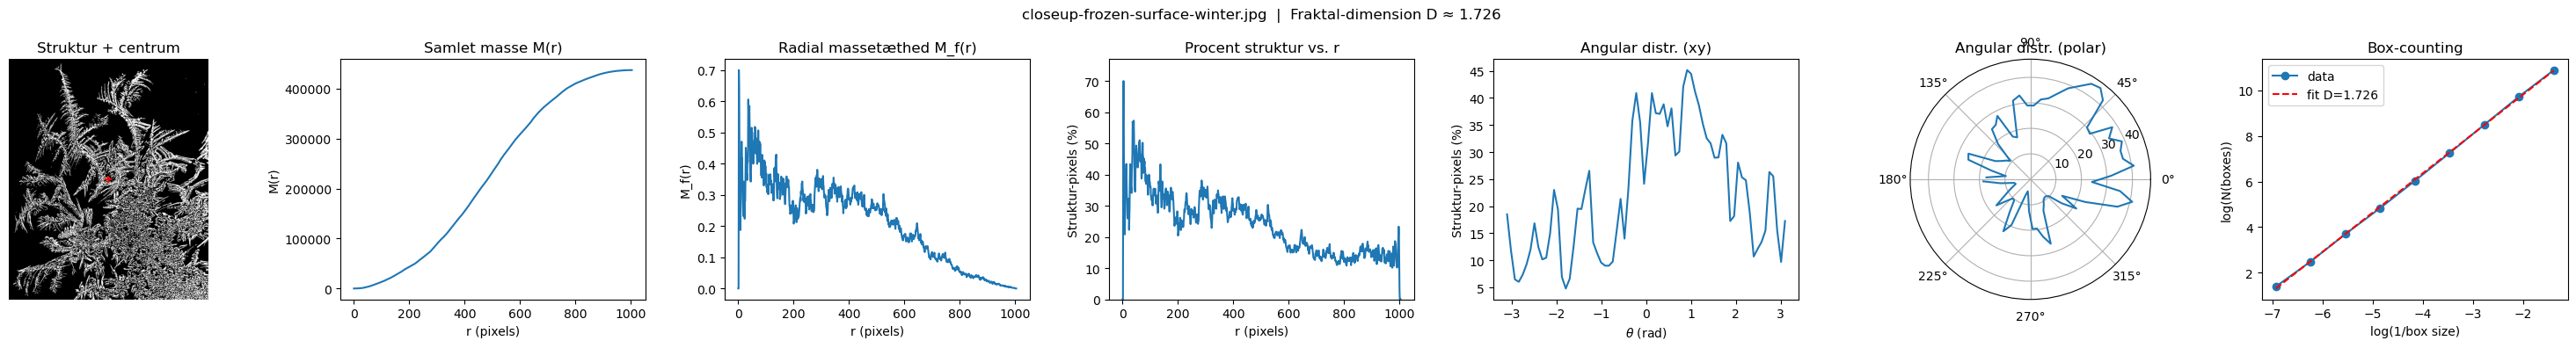

closeup-frozen-surface-winter.jpg: D ≈ 1.726


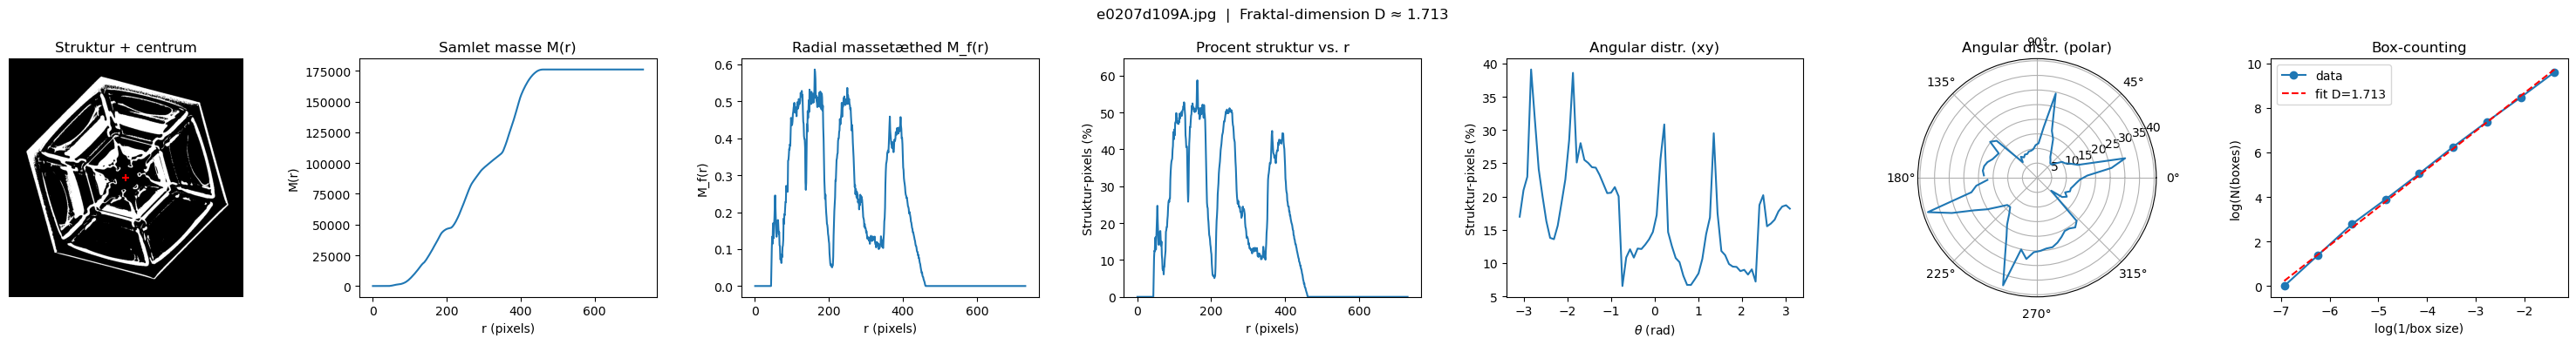

e0207d109A.jpg: D ≈ 1.713


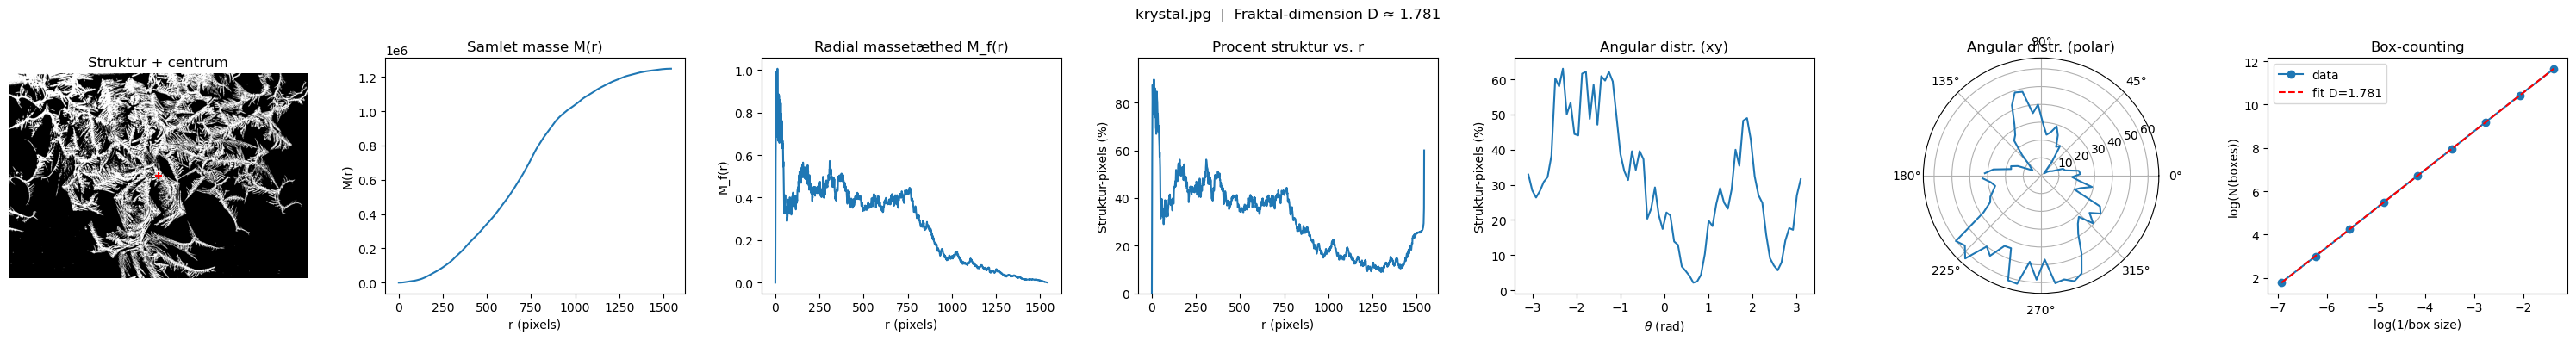

krystal.jpg: D ≈ 1.781


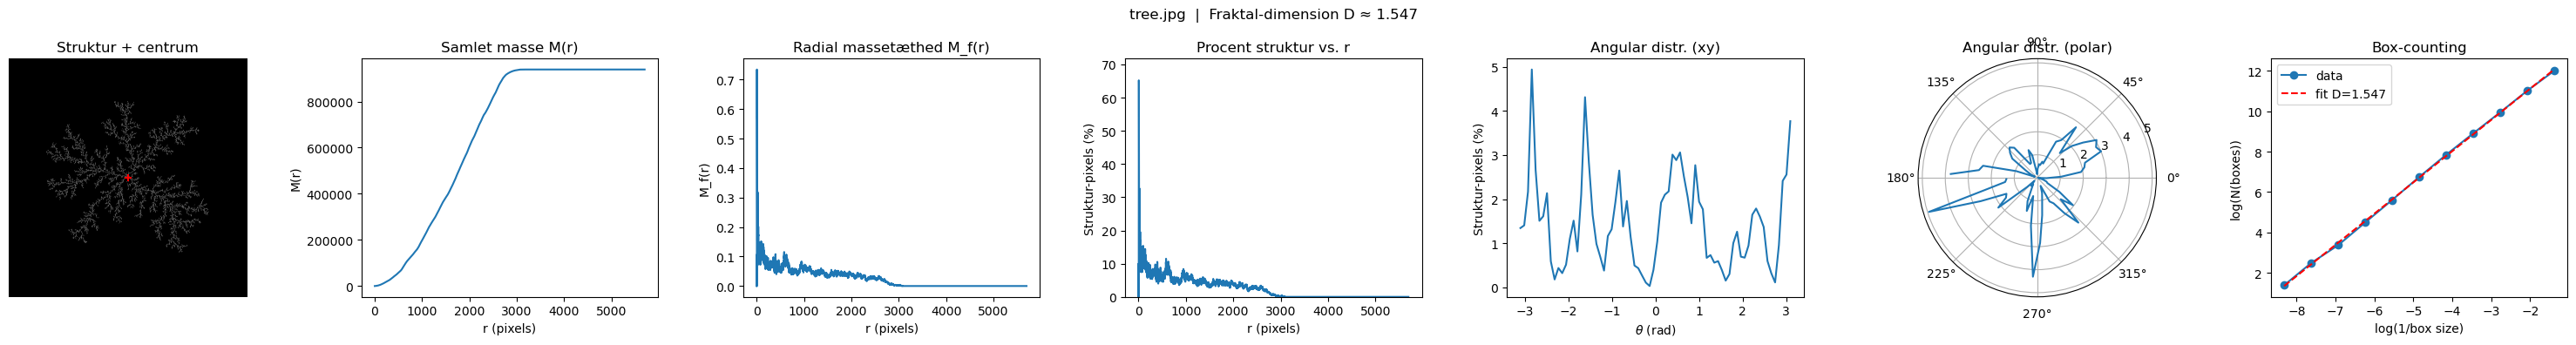

tree.jpg: D ≈ 1.547


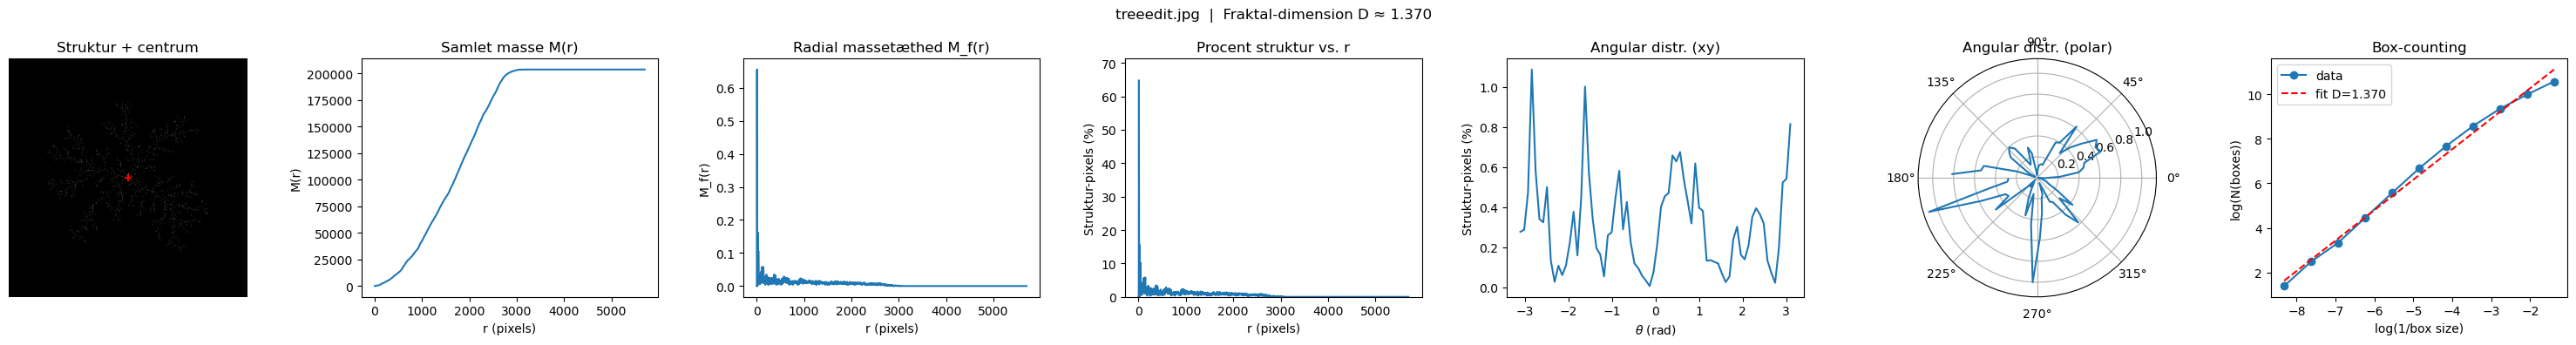

treeedit.jpg: D ≈ 1.370


In [15]:


# ---------- hjælp: boxcount + fraktal-dimension ----------

def boxcount(Z, k):
    S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
            np.arange(0, Z.shape[1], k), axis=1)
    return np.count_nonzero(S)

def fractal_dimension_from_mask(Z):
    p = min(Z.shape)
    n = int(np.floor(np.log2(p)))
    sizes = 2**np.arange(n, 1, -1)
    counts = np.array([boxcount(Z, s) for s in sizes], dtype=float)

    x = np.log(1.0 / sizes)
    y = np.log(counts)
    D, a = np.polyfit(x, y, 1)
    return D, x, y, a

# ---------- hovedanalyse for ét billede ----------

def analyse_billede(filename, t=150, dr=1.0, nbins_theta=72):
    img = Image.open(filename).convert("L")
    I = np.array(img, dtype=float)

    ny, nx = I.shape
    cx, cy = nx / 2.0, ny / 2.0

    y, x = np.indices((ny, nx))
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    theta = np.arctan2(y - cy, x - cx)

    # struktur = mørke pixels
    struct_mask = (I < t).astype(float)

    # ----- radial M(r), M_f(r), procent struktur -----
    r_max = r.max()
    nbins_r = int(r_max // dr)
    bin_edges_r = np.linspace(0, r_max, nbins_r + 1)
    r_centers = 0.5 * (bin_edges_r[:-1] + bin_edges_r[1:])

    deltaM, _ = np.histogram(r, bins=bin_edges_r, weights=struct_mask)
    M = np.cumsum(deltaM)
    Mf = deltaM / (2 * np.pi * r_centers * dr)

    N_tot_r, _ = np.histogram(r, bins=bin_edges_r)
    N_struct_r, _ = np.histogram(r, bins=bin_edges_r, weights=struct_mask)
    frac_r = np.zeros_like(r_centers)
    valid_r = N_tot_r > 0
    frac_r[valid_r] = 100.0 * N_struct_r[valid_r] / N_tot_r[valid_r]

    # ----- angular distribution -----
    bin_edges_th = np.linspace(-np.pi, np.pi, nbins_theta + 1)
    th_centers = 0.5 * (bin_edges_th[:-1] + bin_edges_th[1:])
    N_tot_th, _ = np.histogram(theta, bins=bin_edges_th)
    N_struct_th, _ = np.histogram(theta, bins=bin_edges_th, weights=struct_mask)
    frac_theta = np.zeros_like(th_centers)
    valid_th = N_tot_th > 0
    frac_theta[valid_th] = 100.0 * N_struct_th[valid_th] / N_tot_th[valid_th]

    # ----- fraktal-dimension -----
    Z = (struct_mask > 0).astype(int)
    D, x_log, y_log, a = fractal_dimension_from_mask(Z)

    # ----- samlet figur med 7 akser -----
    fig = plt.figure(figsize=(30, 4))
    fig.suptitle(f"{filename}  |  Fraktal-dimension D ≈ {D:.3f}")

    axs = []
    for i in range(7):
        if i == 5:
            ax = plt.subplot(1, 7, i+1, projection="polar")
        else:
            ax = plt.subplot(1, 7, i+1)
        axs.append(ax)

    # 1) struktur + centrum
    axs[0].imshow(struct_mask, cmap="gray")
    axs[0].scatter([cx], [cy], c="red", s=40, marker="+")
    axs[0].set_title("Struktur + centrum")
    axs[0].axis("off")

    # 2) M(r)
    axs[1].plot(r_centers, M)
    axs[1].set_xlabel("r (pixels)")
    axs[1].set_ylabel("M(r)")
    axs[1].set_title("Samlet masse M(r)")

    # 3) M_f(r)
    axs[2].plot(r_centers, Mf)
    axs[2].set_xlabel("r (pixels)")
    axs[2].set_ylabel("M_f(r)")
    axs[2].set_title("Radial massetæthed M_f(r)")

    # 4) procent struktur vs r
    axs[3].plot(r_centers, frac_r)
    axs[3].set_xlabel("r (pixels)")
    axs[3].set_ylabel("Struktur-pixels (%)")
    axs[3].set_ylim(0, 1.1 * frac_r.max())
    axs[3].set_title("Procent struktur vs. r")

    # 5) angular distribution (kartesisk)
    axs[4].plot(th_centers, frac_theta)
    axs[4].set_xlabel(r"$\theta$ (rad)")
    axs[4].set_ylabel("Struktur-pixels (%)")
    axs[4].set_title("Angular distr. (xy)")

    # 6) angular distribution (polar)
    axs[5].plot(th_centers, frac_theta)
    axs[5].set_title("Angular distr. (polar)")

    # 7) box-counting plot
    axs[6].plot(x_log, y_log, "o-", label="data")
    axs[6].plot(x_log, a + D * x_log, "r--", label=f"fit D={D:.3f}")
    axs[6].set_xlabel("log(1/box size)")
    axs[6].set_ylabel("log(N(boxes))")
    axs[6].set_title("Box-counting")
    axs[6].legend()

    plt.tight_layout()
    plt.show()

    return D

# ---------- kør for alle billeder i mappen ----------

files = sorted(glob.glob("*.jpg"))
for f in files:
    D = analyse_billede(f, t=150, dr=1.0, nbins_theta=72)
    print(f"{f}: D ≈ {D:.3f}")
